In [1]:
# ══════════════════════════════════════════════════════════════════════
# STEP 0  —  Verify image counts across ALL classes (including Others)
# ══════════════════════════════════════════════════════════════════════

import os

train_dir = "C:/Users/gopal/Coding/Model_Training/Dataset/Disease_Classification/Plant_Identification/Train/"
valid_dir = "C:/Users/gopal/Coding/Model_Training/Dataset/Disease_Classification/Plant_Identification/Validation/"

print(f"{'CLASS':<12}  {'TRAIN':>7}  {'VALID':>7}")
print("-" * 30)
expected = ['Apple', 'Corn', 'Grape', 'Others', 'Pepper', 'Potato', 'Strawberry']
for cls in expected:
    t_path = os.path.join(train_dir, cls)
    v_path = os.path.join(valid_dir, cls)
    t_cnt  = len(os.listdir(t_path)) if os.path.exists(t_path) else 0
    v_cnt  = len(os.listdir(v_path)) if os.path.exists(v_path) else 0
    flag   = "" if t_cnt >= 300 else "  ⚠ LOW — need ≥ 300"
    print(f"{cls:<12}  {t_cnt:>7,}  {v_cnt:>7,}{flag}")

print()
print("✅ Looks good if all 7 rows show ≥ 300 train images.")
print("   Others needs at least 1,000 train / 300 valid for reliable rejection.")

CLASS           TRAIN    VALID
------------------------------
Apple           2,536      635
Corn            3,080      772
Grape           1,283      320
Others          5,200    1,972
Pepper          1,996      495
Potato          1,721      431
Strawberry      1,251      314

✅ Looks good if all 7 rows show ≥ 300 train images.
   Others needs at least 1,000 train / 300 valid for reliable rejection.


In [2]:
# ══════════════════════════════════════════════════════════════════════
# STEP 1  —  Imports
# ══════════════════════════════════════════════════════════════════════

import json
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications        import ResNet50
from tensorflow.keras.applications.resnet import preprocess_input   # ✅ correct for ResNet50
from tensorflow.keras.models             import Sequential, load_model
from tensorflow.keras.layers             import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.callbacks          import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

print("TensorFlow:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.10.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# ══════════════════════════════════════════════════════════════════════
# STEP 2  —  Data generators
# ══════════════════════════════════════════════════════════════════════
# ResNet50 preprocess_input expects raw 0–255 pixels.
# It does its own internal normalisation — do NOT rescale=1./255 here.
# The augmentation is stronger than before:
#   shear_range + channel_shift_range handle varied lighting & camera angles
#   fill_mode='reflect' avoids black border artifacts during rotation/shift

IMG_SIZE   = (224, 224)
BATCH_SIZE = 16

train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,   # ✅ ResNet50-specific
    rotation_range         = 25,
    zoom_range             = 0.25,
    horizontal_flip        = True,
    vertical_flip          = True,               # leaf photos can be flipped vertically too
    width_shift_range      = 0.15,
    height_shift_range     = 0.15,
    shear_range            = 10,                 # ✅ handles angled shots
    brightness_range       = [0.6, 1.4],         # ✅ stronger — outdoor lighting varies a lot
    channel_shift_range    = 20,                 # ✅ handles white-balance differences
    fill_mode              = 'reflect',          # ✅ no black borders on shift/rotation
)

valid_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,   # ✅ same — must match training
)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = True,
)

valid_data = valid_datagen.flow_from_directory(
    valid_dir,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False,   # ✅ must be False for evaluation to work correctly
)

NUM_CLASSES = len(train_data.class_indices)   # should be 7
CLASS_NAMES = list(train_data.class_indices.keys())

print("Class indices :", train_data.class_indices)
print("Total classes :", NUM_CLASSES)
assert NUM_CLASSES == 7, (
    f"Expected 7 classes (6 plants + Others), got {NUM_CLASSES}.\n"
    "Make sure the Others/ folder exists in both Train/ and Validation/."
)

# ✅ Save class map immediately — needed for safe inference later
with open('stage1_class_indices.json', 'w') as f:
    json.dump(train_data.class_indices, f, indent=2)
print("\n✅ Saved class indices to stage1_class_indices.json")

Found 17067 images belonging to 7 classes.
Found 4939 images belonging to 7 classes.
Class indices : {'Apple': 0, 'Corn': 1, 'Grape': 2, 'Others': 3, 'Pepper': 4, 'Potato': 5, 'Strawberry': 6}
Total classes : 7

✅ Saved class indices to stage1_class_indices.json


In [4]:
# ══════════════════════════════════════════════════════════════════════
# STEP 3  —  Class weights  (handles imbalanced Others class)
# ══════════════════════════════════════════════════════════════════════

labels_flat = train_data.classes

weights = compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(labels_flat),
    y            = labels_flat,
)
class_weight_dict = dict(enumerate(weights))

print("Class weights:")
for idx, name in enumerate(CLASS_NAMES):
    print(f"  [{idx}] {name:<10}  weight = {class_weight_dict[idx]:.3f}")
print()
print("Higher weight = Keras penalises mistakes on that class more.")
print("Others typically gets a higher weight if it has fewer images.")

Class weights:
  [0] Apple       weight = 0.961
  [1] Corn        weight = 0.792
  [2] Grape       weight = 1.900
  [3] Others      weight = 0.469
  [4] Pepper      weight = 1.222
  [5] Potato      weight = 1.417
  [6] Strawberry  weight = 1.949

Higher weight = Keras penalises mistakes on that class more.
Others typically gets a higher weight if it has fewer images.


In [5]:
# ══════════════════════════════════════════════════════════════════════
# STEP 4  —  Build model  (ResNet50 backbone)
# ══════════════════════════════════════════════════════════════════════
#
# Why ResNet50 over EfficientNetV2-S?
#   - One of the most widely validated backbones for transfer learning
#   - Strong residual connections preserve gradient flow through deep layers
#   - Pretrained on ImageNet-1k — robust feature representations
#     for fine-grained textures like leaf veins, spots, colour patterns
#   - Model size ~98 MB, well-supported across all TF versions
#   - Reliable baseline for plant/leaf classification tasks
#
# Head architecture  (unchanged from original design):
#   GlobalAveragePooling2D → BatchNorm → Dense(512) → Dropout(0.4)
#                          → Dense(256) → Dropout(0.3) → softmax(7)

base_model = ResNet50(
    weights     = 'imagenet',
    include_top = False,
    input_shape = (224, 224, 3)
)
base_model.trainable = False   # frozen for Phase 1 — only train the head

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dense(512, activation='relu'),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(NUM_CLASSES, activation='softmax'),   # 7 output classes
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy'],
)

model.summary()
print(f"\n✅ Output: {NUM_CLASSES} classes — {CLASS_NAMES}")

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet50 (Functional)       (None, 7, 7, 2048)        23587712  
                                                                 
 global_average_pooling2d (G  (None, 2048)             0         
 lobalAveragePooling2D)                                          
                                                                 
 batch_normalization (BatchN  (None, 2048)             8192      
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 dropout (Dropout)           (None, 512)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               1

In [6]:
# ══════════════════════════════════════════════════════════════════════
# STEP 5  —  Callbacks
# ══════════════════════════════════════════════════════════════════════

checkpoint = ModelCheckpoint(
    'stage1_plant_identifier_best.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 1,
)

early_stop = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 5,
    restore_best_weights = True,
    verbose              = 1,
)

reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.3,
    patience = 2,
    min_lr   = 1e-7,
    verbose  = 1,
)

In [7]:
# ══════════════════════════════════════════════════════════════════════
# STEP 6  —  Phase 1 training  (head only, base frozen)
# ══════════════════════════════════════════════════════════════════════
# Train only the Dense layers we added.
# ResNet50 base stays frozen — its ImageNet weights are preserved.
# This phase runs fast and gets the head to a good starting point.

print("Phase 1: Training head only (base frozen)")
print(f"Trainable params: {sum(tf.size(w).numpy() for w in model.trainable_weights):,}")
print("-" * 50)

history_phase1 = model.fit(
    train_data,
    validation_data = valid_data,
    epochs          = 12,
    class_weight    = class_weight_dict,
    callbacks       = [checkpoint, early_stop, reduce_lr],
)

Phase 1: Training head only (base frozen)
Trainable params: 1,186,311
--------------------------------------------------
Epoch 1/12
 335/1067 [========>.....................] - ETA: 2:23 - loss: 0.4311 - accuracy: 0.8924

C:\Users\gopal\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


1067/1067 [==============================] - ETA: 0s - loss: 0.2647 - accuracy: 0.9370
Epoch 1: val_accuracy improved from -inf to 0.98724, saving model to stage1_plant_identifier_best.keras
1067/1067 [==============================] - 259s 233ms/step - loss: 0.2647 - accuracy: 0.9370 - val_loss: 0.0390 - val_accuracy: 0.9872 - lr: 0.0010
Epoch 2/12
1067/1067 [==============================] - ETA: 0s - loss: 0.1464 - accuracy: 0.9695
Epoch 2: val_accuracy improved from 0.98724 to 0.99656, saving model to stage1_plant_identifier_best.keras
1067/1067 [==============================] - 237s 222ms/step - loss: 0.1464 - accuracy: 0.9695 - val_loss: 0.0134 - val_accuracy: 0.9966 - lr: 0.0010
Epoch 3/12
1067/1067 [==============================] - ETA: 0s - loss: 0.1145 - accuracy: 0.9734
Epoch 3: val_accuracy did not improve from 0.99656
1067/1067 [==============================] - 235s 220ms/step - loss: 0.1145 - accuracy: 0.9734 - val_loss: 0.0167 - val_accuracy: 0.9941 - lr: 0.0010
Epoch

In [8]:
# ══════════════════════════════════════════════════════════════════════
# STEP 7  —  Phase 2 fine-tuning  (unfreeze last 60 layers)
# ══════════════════════════════════════════════════════════════════════
# Why 60 layers?
#   ResNet50 has 175 layers total. The last 60 cover the final two
#   residual blocks (conv4 & conv5) which encode high-level texture
#   features — veins, spots, colour patterns — most relevant for
#   leaf discrimination. Keep LR very low (1e-5) to avoid
#   destroying the pretrained weights.

base_model.trainable = True
for layer in base_model.layers[:-60]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Phase 2: Fine-tuning last {trainable_count} layers of ResNet50")
print("-" * 50)

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),  # very low LR for fine-tuning
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy'],
)

checkpoint2 = ModelCheckpoint(
    'stage1_plant_identifier_best.keras',
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 1,
)

early_stop2 = EarlyStopping(
    monitor              = 'val_accuracy',
    patience             = 6,
    restore_best_weights = True,
    verbose              = 1,
)

history_phase2 = model.fit(
    train_data,
    validation_data = valid_data,
    epochs          = 20,
    class_weight    = class_weight_dict,
    callbacks       = [checkpoint2, early_stop2, reduce_lr],
)

Phase 2: Fine-tuning last 60 layers of ResNet50
--------------------------------------------------
Epoch 1/20
1067/1067 [==============================] - ETA: 0s - loss: 0.0505 - accuracy: 0.9883
Epoch 1: val_accuracy improved from -inf to 0.99939, saving model to stage1_plant_identifier_best.keras
1067/1067 [==============================] - 218s 200ms/step - loss: 0.0505 - accuracy: 0.9883 - val_loss: 0.0015 - val_accuracy: 0.9994 - lr: 1.0000e-05
Epoch 2/20
1067/1067 [==============================] - ETA: 0s - loss: 0.0415 - accuracy: 0.9905
Epoch 2: val_accuracy improved from 0.99939 to 0.99960, saving model to stage1_plant_identifier_best.keras
1067/1067 [==============================] - 216s 202ms/step - loss: 0.0415 - accuracy: 0.9905 - val_loss: 9.9110e-04 - val_accuracy: 0.9996 - lr: 1.0000e-05
Epoch 3/20
1067/1067 [==============================] - ETA: 0s - loss: 0.0359 - accuracy: 0.9908
Epoch 3: val_accuracy did not improve from 0.99960
1067/1067 [======================

In [9]:
# ══════════════════════════════════════════════════════════════════════
# STEP 8  —  Evaluate best model
# ══════════════════════════════════════════════════════════════════════

best_model = load_model('stage1_plant_identifier_best.keras')
loss, acc  = best_model.evaluate(valid_data, verbose=1)
print(f"\n✅ Best model — Val Accuracy: {acc*100:.2f}%  |  Val Loss: {loss:.4f}")

309/309 [==============================] - 31s 96ms/step - loss: 5.1571e-04 - accuracy: 1.0000

✅ Best model — Val Accuracy: 100.00%  |  Val Loss: 0.0005


In [12]:
pip install pandas

  Using cached pandas-2.3.3-cp310-cp310-win_amd64.whl (11.3 MB)
Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'C:\Users\gopal\AppData\Local\Programs\Python\Python310\python.exe -m pip install --upgrade pip' command.


175/309 [===============>..............] - ETA: 15s

C:\Users\gopal\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


309/309 [==============================] - 133s 429ms/step

  PER-CLASS ACCURACY REPORT
              precision    recall  f1-score   support

       Apple       1.00      1.00      1.00       635
        Corn       1.00      1.00      1.00       772
       Grape       1.00      1.00      1.00       320
      Others       1.00      1.00      1.00      1972
      Pepper       1.00      1.00      1.00       495
      Potato       1.00      1.00      1.00       431
  Strawberry       1.00      1.00      1.00       314

    accuracy                           1.00      4939
   macro avg       1.00      1.00      1.00      4939
weighted avg       1.00      1.00      1.00      4939



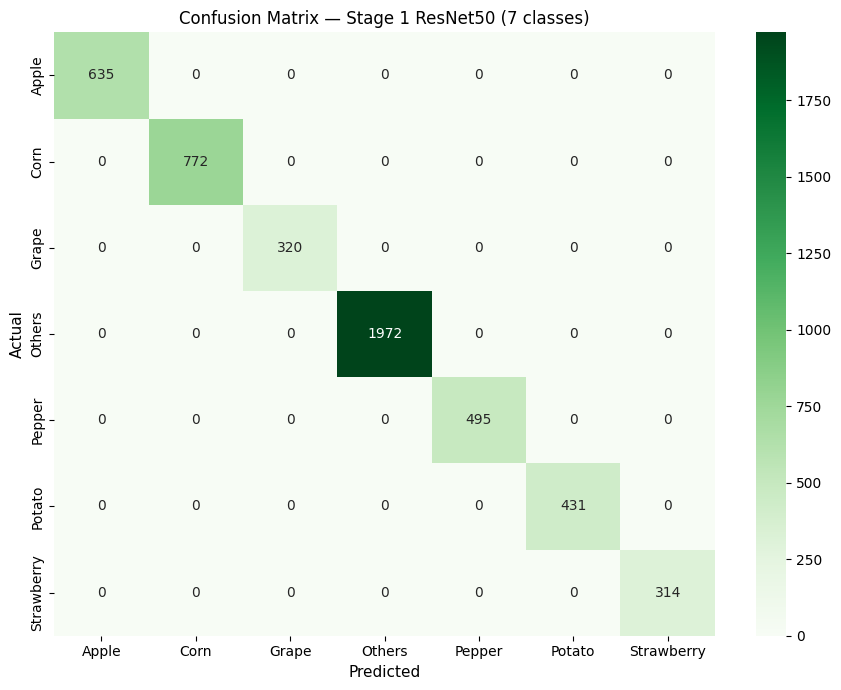


⚠  Check the 'Others' row:
   High recall on Others = model reliably rejects non-leaf images.


In [13]:
# ══════════════════════════════════════════════════════════════════════
# STEP 9  —  Per-class accuracy report + confusion matrix
# ══════════════════════════════════════════════════════════════════════

import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

valid_data.reset()
y_pred_probs = best_model.predict(valid_data, verbose=1)
y_pred       = np.argmax(y_pred_probs, axis=1)
y_true       = valid_data.classes
class_labels = list(valid_data.class_indices.keys())

print("\n" + "=" * 60)
print("  PER-CLASS ACCURACY REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Greens',
    xticklabels=class_labels, yticklabels=class_labels, ax=ax
)
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual',    fontsize=11)
ax.set_title('Confusion Matrix — Stage 1 ResNet50 (7 classes)', fontsize=12)
plt.tight_layout()
plt.savefig('stage1_confusion_matrix.png', dpi=150)
plt.show()

print("\n⚠  Check the 'Others' row:")
print("   High recall on Others = model reliably rejects non-leaf images.")

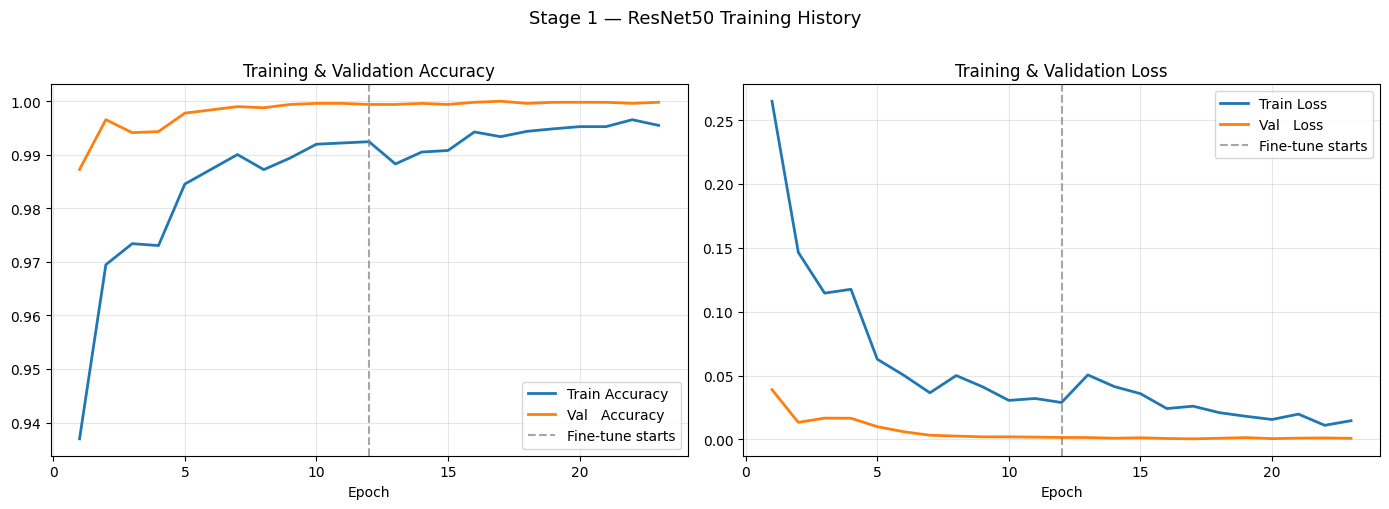

Plot saved as stage1_training_history.png


In [14]:
# ══════════════════════════════════════════════════════════════════════
# STEP 10  —  Training history plot
# ══════════════════════════════════════════════════════════════════════

def _join(h1, h2, key):
    return h1.history[key] + h2.history[key]

train_acc  = _join(history_phase1, history_phase2, 'accuracy')
val_acc    = _join(history_phase1, history_phase2, 'val_accuracy')
train_loss = _join(history_phase1, history_phase2, 'loss')
val_loss   = _join(history_phase1, history_phase2, 'val_loss')
phase1_end = len(history_phase1.history['accuracy'])
epochs_rng = range(1, len(train_acc) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, tr, vl, title in zip(
    axes,
    [train_acc,  train_loss],
    [val_acc,    val_loss],
    ['Accuracy', 'Loss']
):
    ax.plot(epochs_rng, tr, label=f'Train {title}', linewidth=2)
    ax.plot(epochs_rng, vl, label=f'Val   {title}', linewidth=2)
    ax.axvline(x=phase1_end, color='gray', linestyle='--',
               alpha=0.7, label='Fine-tune starts')
    ax.set_title(f'Training & Validation {title}')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Stage 1 — ResNet50 Training History', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('stage1_training_history.png', dpi=150)
plt.show()
print('Plot saved as stage1_training_history.png')

In [15]:
# ══════════════════════════════════════════════════════════════════════
# STEP 11  —  Save final model + class map
# ══════════════════════════════════════════════════════════════════════

best_model.save('stage1_plant_identifier_resnet50.keras')

# class_indices.json was already saved in Step 2, but re-save to be safe
with open('stage1_class_indices.json', 'w') as f:
    json.dump(train_data.class_indices, f, indent=2)

print('✅ Saved files:')
print('   stage1_plant_identifier_resnet50.keras  — final model')
print('   stage1_plant_identifier_best.keras      — best checkpoint')
print('   stage1_class_indices.json               — class map (required for inference)')
print()
print('Class order:')
for name, idx in sorted(train_data.class_indices.items(), key=lambda x: x[1]):
    print(f'  [{idx}] {name}')

✅ Saved files:
   stage1_plant_identifier_resnet50.keras  — final model
   stage1_plant_identifier_best.keras      — best checkpoint
   stage1_class_indices.json               — class map (required for inference)

Class order:
  [0] Apple
  [1] Corn
  [2] Grape
  [3] Others
  [4] Pepper
  [5] Potato
  [6] Strawberry


In [16]:
# ══════════════════════════════════════════════════════════════════════
# STEP 12  —  Full Metrics Summary (for cross-model comparison)
# ══════════════════════════════════════════════════════════════════════
# Computes every metric needed for the comparison table:
#   Must-have : Accuracy, Precision, Recall, F1, Inference Time, Model Size
#   Good-to-add: Parameter count, Train vs Val accuracy
#   (Confusion matrix was already produced + saved in Step 9)
#
# Reuses variables already created earlier in this notebook:
#   best_model, y_true, y_pred, valid_data, train_acc, val_acc
#
# Results are printed AND saved to metrics_summary_ResNet50.json so
# they can be combined with the other models' results later.

import os
import time
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

MODEL_NAME = "ResNet50"
MODEL_FILE = "stage1_plant_identifier_resnet50.keras"   # saved in Step 11

# ---------- 1. Accuracy / Precision / Recall / F1 ----------
overall_acc = accuracy_score(y_true, y_pred)

precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average='macro', zero_division=0
)
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted', zero_division=0
)

# ---------- 2. Parameter counts ----------
total_params         = model.count_params()
trainable_params     = int(sum(tf.size(w).numpy() for w in model.trainable_weights))
non_trainable_params = total_params - trainable_params

# ---------- 3. Model size on disk (MB) ----------
model_size_mb = os.path.getsize(MODEL_FILE) / (1024 ** 2) if os.path.exists(MODEL_FILE) else float('nan')

# ---------- 4. Inference time ----------
# Warm-up call first (excludes one-time graph-tracing / XLA overhead)
sample_batch, _ = next(iter(valid_data))
_ = best_model.predict(sample_batch, verbose=0)

# 4a. Single-image latency — average over many individual predictions
N_SINGLE = 50
single_img = sample_batch[:1]
start = time.perf_counter()
for _ in range(N_SINGLE):
    _ = best_model.predict(single_img, verbose=0)
end = time.perf_counter()
single_image_ms = ((end - start) / N_SINGLE) * 1000

# 4b. Batched throughput — average over the full validation set
valid_data.reset()
start = time.perf_counter()
_ = best_model.predict(valid_data, verbose=0)
end = time.perf_counter()
total_val_images = valid_data.samples
batch_inference_ms_per_image = ((end - start) / total_val_images) * 1000

# ---------- 5. Train vs Validation accuracy (final epoch reached) ----------
final_train_acc = train_acc[-1]
final_val_acc   = val_acc[-1]

# ---------- 6. Print summary ----------
print("=" * 65)
print(f"  MODEL COMPARISON METRICS  —  {MODEL_NAME}")
print("=" * 65)
print(f"{'Accuracy':<28}: {overall_acc*100:.2f}%")
print(f"{'Precision (macro)':<28}: {precision_macro:.4f}")
print(f"{'Recall (macro)':<28}: {recall_macro:.4f}")
print(f"{'F1 Score (macro)':<28}: {f1_macro:.4f}")
print(f"{'Precision (weighted)':<28}: {precision_weighted:.4f}")
print(f"{'Recall (weighted)':<28}: {recall_weighted:.4f}")
print(f"{'F1 Score (weighted)':<28}: {f1_weighted:.4f}")
print("-" * 65)
print(f"{'Inference time (1 image)':<28}: {single_image_ms:.2f} ms")
print(f"{'Inference time (batched avg)':<28}: {batch_inference_ms_per_image:.2f} ms/image")
print(f"{'Model size on disk':<28}: {model_size_mb:.2f} MB")
print("-" * 65)
print(f"{'Total parameters':<28}: {total_params:,}")
print(f"{'Trainable parameters':<28}: {trainable_params:,}")
print(f"{'Non-trainable parameters':<28}: {non_trainable_params:,}")
print("-" * 65)
print(f"{'Final train accuracy':<28}: {final_train_acc*100:.2f}%")
print(f"{'Final val accuracy':<28}: {final_val_acc*100:.2f}%")
print("=" * 65)

# ---------- 7. Save to JSON for later cross-model aggregation ----------
metrics_summary = {
    "model_name": MODEL_NAME,
    "accuracy": overall_acc,
    "precision_macro": precision_macro,
    "recall_macro": recall_macro,
    "f1_macro": f1_macro,
    "precision_weighted": precision_weighted,
    "recall_weighted": recall_weighted,
    "f1_weighted": f1_weighted,
    "inference_time_single_image_ms": single_image_ms,
    "inference_time_batch_ms_per_image": batch_inference_ms_per_image,
    "model_size_mb": model_size_mb,
    "total_params": int(total_params),
    "trainable_params": int(trainable_params),
    "non_trainable_params": int(non_trainable_params),
    "final_train_accuracy": float(final_train_acc),
    "final_val_accuracy": float(final_val_acc),
}

out_file = f"metrics_summary_{MODEL_NAME}.json"
with open(out_file, "w") as f:
    json.dump(metrics_summary, f, indent=2)

print(f"\n✅ Saved: {out_file}")
print("   Run 'compare_models.py' after all 5 notebooks have been executed")
print("   once to build the final side-by-side comparison table.")


C:\Users\gopal\AppData\Local\Programs\Python\Python310\lib\site-packages\PIL\Image.py:1056: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


  MODEL COMPARISON METRICS  —  ResNet50
Accuracy                    : 100.00%
Precision (macro)           : 1.0000
Recall (macro)              : 1.0000
F1 Score (macro)            : 1.0000
Precision (weighted)        : 1.0000
Recall (weighted)           : 1.0000
F1 Score (weighted)         : 1.0000
-----------------------------------------------------------------
Inference time (1 image)    : 71.66 ms
Inference time (batched avg): 6.08 ms/image
Model size on disk          : 241.93 MB
-----------------------------------------------------------------
Total parameters            : 24,778,119
Trainable parameters        : 19,255,559
Non-trainable parameters    : 5,522,560
-----------------------------------------------------------------
Final train accuracy        : 99.55%
Final val accuracy          : 99.98%

✅ Saved: metrics_summary_ResNet50.json
   Run 'compare_models.py' after all 5 notebooks have been executed
   once to build the final side-by-side comparison table.
